## Training code for a random survival forest, taken from the scikit-survival User Guide

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

from sksurv.datasets import load_gbsg2
from sksurv.ensemble import RandomSurvivalForest
from sksurv.preprocessing import OneHotEncoder

set_config(display="text")  # displays text representation of estimators

In [2]:
X, y = load_gbsg2()

grade_str = X.loc[:, "tgrade"].to_numpy(dtype="str")[:, np.newaxis]
grade_num = OrdinalEncoder(categories=[["I", "II", "III"]]).fit_transform(grade_str)

X_no_grade = X.drop("tgrade", axis=1)
Xt = OneHotEncoder().fit_transform(X_no_grade)
Xt.loc[:, "tgrade"] = grade_num

In [3]:
random_state = 20

X_train, X_test, y_train, y_test = train_test_split(Xt, y, test_size=0.25, random_state=random_state)

### Cox model

In [4]:
from sksurv.linear_model import CoxnetSurvivalAnalysis
cox = CoxnetSurvivalAnalysis(fit_baseline_model=True)
cox.fit(X_train, y_train)

CoxnetSurvivalAnalysis(fit_baseline_model=True)

In [5]:
cox.score(X_test, y_test)

np.float64(0.6506813417190775)

### RSF

In [6]:
rsf = RandomSurvivalForest(
    n_estimators=1000, min_samples_split=10, min_samples_leaf=15, n_jobs=-1, random_state=random_state
)
rsf.fit(X_train, y_train)

RandomSurvivalForest(min_samples_leaf=15, min_samples_split=10,
                     n_estimators=1000, n_jobs=-1, random_state=20)

In [7]:
c_index = rsf.score(X_test, y_test)
f"{c_index:.5f}"

'0.67453'

## Antolini C-index

In [8]:
def sksurv_predict_survival(model, X, time_grid):
    return np.array([[f(t)  for t in time_grid] for f in model.predict_survival_function(X)])

In [9]:
event_times = y_test['time'][y_test['cens']]
even_time_grid = np.linspace(0, event_times.max(), 30)

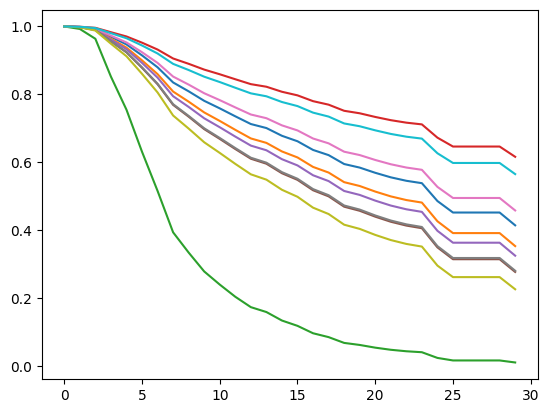

In [10]:
cox_even_time_survs = sksurv_predict_survival(cox, X_test, even_time_grid)
plt.plot(cox_even_time_survs[:10].T);

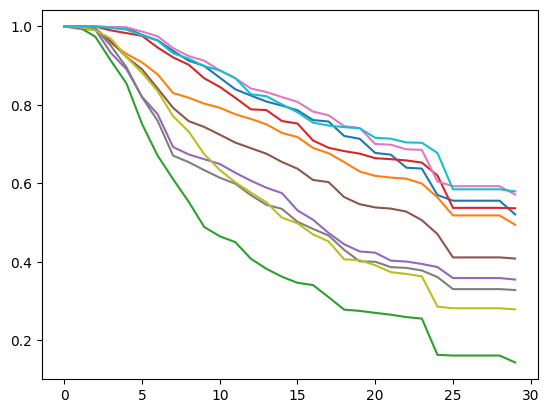

In [11]:
rsf_even_time_preds = sksurv_predict_survival(rsf, X_test, even_time_grid)
plt.plot(rsf_even_time_preds[:10].T);

Note: Antolini's C-index expects **failure probability** estimates (i.e., `1 - S(t)`) in a matrix of shape `(n_samples, n_event_times)` — one row per individual, one column per event time. Since scikit-survival's `predict_survival_function` returns survival probabilities `S(t)`, we convert with `1 - S(t)` before passing to `c_index_antolini`.

In [12]:
from survmetr import c_index_antolini

cox_event_time_survs = sksurv_predict_survival(cox, X_test, event_times)
c_index_antolini(1 - cox_event_time_survs, y_test, return_all=True)

{'c_index': 0.6508519003931847,
 'concordant': 4966,
 'comparable': 7630,
 'tied_risk': 0,
 'discordant': 2664,
 'numerator': 4966.0}

In [13]:
cox.score(X_test, y_test)
from sksurv.metrics import concordance_index_censored
concordance_index_censored(y_test['cens'], y_test['time'], cox.predict(X_test))

(np.float64(0.6506813417190775),
 np.int64(4966),
 np.int64(2666),
 np.int64(0),
 np.int64(2))

In [14]:
rsf_event_time_preds = sksurv_predict_survival(rsf, X_test, event_times)
c_index_antolini(1 - rsf_event_time_preds, y_test, return_all=True)

{'c_index': 0.690694626474443,
 'concordant': 5270,
 'comparable': 7630,
 'tied_risk': 0,
 'discordant': 2360,
 'numerator': 5270.0}

In [15]:
concordance_index_censored(y_test['cens'], y_test['time'], rsf.predict(X_test))

(np.float64(0.6745283018867925),
 np.int64(5148),
 np.int64(2484),
 np.int64(0),
 np.int64(2))

## Time-Dependent Classification Metrics (Brier Score, Log Loss)

`make_survival_scorer` turns any sklearn classification metric into a time-dependent survival scorer. At each evaluation time $t$, it creates binary labels (event by time $t$ vs. still at risk) and scores the model's predicted probabilities.

scikit-survival models use `predict_survival_function` which returns step-function objects, while `make_survival_scorer` expects a `predict_survival(X, times)` method returning a matrix. We define a thin adapter below.

In [16]:
class SksurvAdapter:
    """Wrap a scikit-survival model so that make_survival_scorer can call predict_survival(X, times)."""
    def __init__(self, model):
        self.model = model

    def predict_survival(self, X, times):
        surv_fns = self.model.predict_survival_function(X)
        return np.array([[fn(t) for t in times] for fn in surv_fns])

### Brier Score at Quartiles

In [17]:
from sklearn.metrics import brier_score_loss
from survmetr import make_survival_scorer

brier_at_quartiles = make_survival_scorer(
    brier_score_loss,
    needs="failure",
    classification=True,
    time_mode="quantiles",
    time_values=[0.25, 0.5, 0.75],
)

cox_brier = brier_at_quartiles(SksurvAdapter(cox), X_test, y_test)
rsf_brier = brier_at_quartiles(SksurvAdapter(rsf), X_test, y_test)

print(f"Mean Brier score at quartiles (lower is better):")
print(f"  Cox:  {cox_brier:.4f}")
print(f"  RSF:  {rsf_brier:.4f}")

Mean Brier score at quartiles (lower is better):
  Cox:  0.1437
  RSF:  0.1382


In [18]:
# Per-quartile breakdown
brier_per_quartile = make_survival_scorer(
    brier_score_loss,
    needs="failure",
    classification=True,
    aggregate="no",
    time_mode="quantiles",
    time_values=[0.25, 0.5, 0.75],
)

cox_brier_q = brier_per_quartile(SksurvAdapter(cox), X_test, y_test)
rsf_brier_q = brier_per_quartile(SksurvAdapter(rsf), X_test, y_test)

pd.DataFrame(
    {"Cox": cox_brier_q, "RSF": rsf_brier_q},
    index=["Q1 (25%)", "Q2 (50%)", "Q3 (75%)"],
)

,Cox,RSF
Q1 (25%),0.088633,0.084085
Q2 (50%),0.145687,0.141112
Q3 (75%),0.196884,0.189445


### Log Loss at Quartiles

In [19]:
from sklearn.metrics import log_loss

logloss_at_quartiles = make_survival_scorer(
    log_loss,
    needs="failure",
    classification=True,
    time_mode="quantiles",
    time_values=[0.25, 0.5, 0.75],
)

cox_ll = logloss_at_quartiles(SksurvAdapter(cox), X_test, y_test)
rsf_ll = logloss_at_quartiles(SksurvAdapter(rsf), X_test, y_test)

print(f"Mean log loss at quartiles (lower is better):")
print(f"  Cox:  {cox_ll:.4f}")
print(f"  RSF:  {rsf_ll:.4f}")

Mean log loss at quartiles (lower is better):
  Cox:  0.4527
  RSF:  0.4304


In [20]:
# Per-quartile breakdown
logloss_per_quartile = make_survival_scorer(
    log_loss,
    needs="failure",
    classification=True,
    aggregate="no",
    time_mode="quantiles",
    time_values=[0.25, 0.5, 0.75],
)

cox_ll_q = logloss_per_quartile(SksurvAdapter(cox), X_test, y_test)
rsf_ll_q = logloss_per_quartile(SksurvAdapter(rsf), X_test, y_test)

pd.DataFrame(
    {"Cox": cox_ll_q, "RSF": rsf_ll_q},
    index=["Q1 (25%)", "Q2 (50%)", "Q3 (75%)"],
)

,Cox,RSF
Q1 (25%),0.316165,0.285191
Q2 (50%),0.461378,0.442317
Q3 (75%),0.580613,0.563727
